In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
from google.colab import files

uploaded = files.upload()

Saving 10mM(1) MP.xlsx to 10mM(1) MP.xlsx


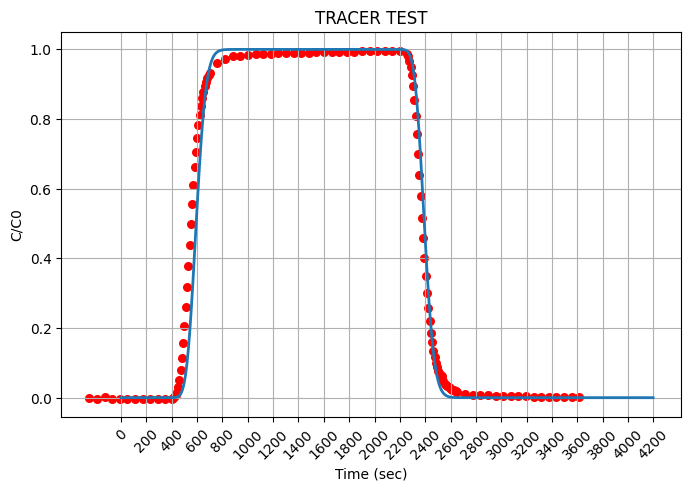

1585
0.9999999999999835
2393


In [4]:
df = pd.read_excel("Tracer.xlsx")
exp_time = pd.to_numeric(df.iloc[2:, 3], errors='coerce')
exp_time -= 250
exp_btc  = pd.to_numeric(df.iloc[2:, 7], errors='coerce')
exp_time = exp_time.dropna()
exp_btc = exp_btc.dropna()
L = 15.0
dx = 0.1
porosity = 0.4
v = 0.01/ porosity
D = 0.001
dt = 1
t_end = 4200

Cin = 1.0
injection_time = 1800

katt = 0.0
kdet = 0.0

Smax = 1.0

x = np.arange(0, L + dx, dx)

Nx = len(x)
Nt = int(t_end / dt)

C = np.zeros(Nx)
S = np.zeros(Nx)

BTC = []
time = []

for n in range(Nt):

    t = n * dt

    C_old = C.copy()
    S_old = S.copy()

    if t <= injection_time:
        C[0] = Cin
    else:
        C[0] = 0.0

    C[-1] = C[-2]
    S[0] = S_old[0]
    S[-1] = S_old[-2]

    for i in range(1, Nx - 1):

        advective_term = ( -v*(C_old[i] - C_old[i - 1]) / dx )

        dispersive_term = ( D*(C_old[i + 1]- 2 * C_old[i]+ C_old[i - 1])/ dx**2)

        blocking_factor = (1.0 - S_old[i] / Smax)

        if blocking_factor < 0:
            blocking_factor = 0

        attachment_term = (-katt*C_old[i]*blocking_factor)

        detachment_term = (kdet*S_old[i])


        C[i] = (C_old[i] + dt*(advective_term + dispersive_term + attachment_term + detachment_term))

        S[i] = (S_old[i] + dt*(katt*C_old[i]*blocking_factor - kdet*S_old[i]))

    BTC.append(C[-1])
    time.append(t)


plt.figure(figsize=(8,5))
plt.plot(time, BTC, linewidth=2)

plt.xlabel("Time (sec)")
plt.ylabel("C/C0")
plt.xticks(np.arange(0, t_end + 1, 200), rotation = 45)
plt.title("TRACER TEST")

plt.grid(True)
plt.scatter(
    exp_time,
    exp_btc,
    color='red',
    s=30,
    label='Experimental Tracer'
)

plt.show()
peak_index = np.argmax(BTC)

print(time[peak_index])
print(BTC[peak_index])
idx = np.argmin(np.abs(np.array(BTC)-0.5))
print(time[idx])

In [5]:
from google.colab import files

uploaded = files.upload()

Saving 10mM(1) MP.xlsx to 10mM(1) MP (1).xlsx


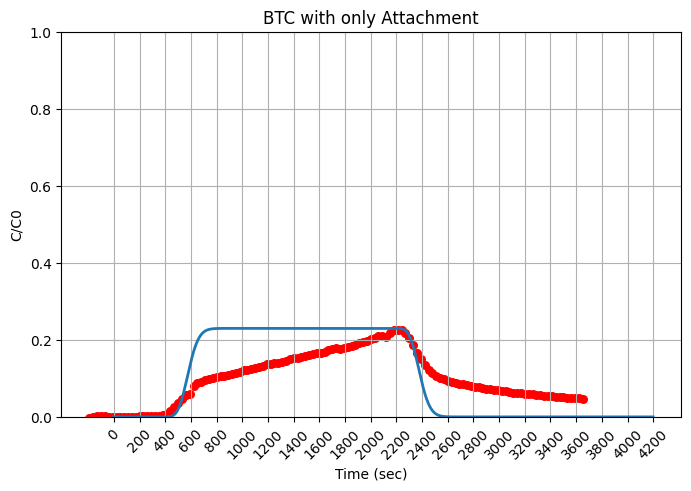

1329
0.2299410038713923
1327


In [6]:
# ADVECTION ONLY PLOT
L = 15.0
dx = 0.1
porosity = 0.4
v = 0.01 / porosity
D = 0.001312
dt = 1
t_end = 4200

df = pd.read_excel("10mM(1) MP.xlsx", sheet_name = 1)
exp_time = pd.to_numeric(df.iloc[2:, 0], errors='coerce')
exp_time -= 250
exp_btc  = pd.to_numeric(df.iloc[2:, 1], errors='coerce')
exp_time = exp_time.dropna()
exp_btc = exp_btc.dropna()


Cin = 1.0
injection_time = 1800

katt = 0.0025
kdet = 0.0

Smax = 1.0

x = np.arange(0, L + dx, dx)

Nx = len(x)
Nt = int(t_end / dt)

C = np.zeros(Nx)
S = np.zeros(Nx)

BTC = []
time = []

for n in range(Nt):

    t = n * dt

    C_old = C.copy()
    S_old = S.copy()

    if t <= injection_time:
        C[0] = Cin
    else:
        C[0] = 0.0

    C[-1] = C[-2]
    S[0] = S_old[0]
    S[-1] = S_old[-2]

    for i in range(1, Nx - 1):

        advective_term = (-v * (C_old[i] - C_old[i - 1]) / dx)


        dispersive_term = (D * (C_old[i + 1] - 2 * C_old[i] + C_old[i - 1]) / dx**2)

        blocking_factor = 1

        if blocking_factor < 0:
            blocking_factor = 0

        attachment_term = (-katt * C_old[i] * blocking_factor)

        detachment_term = (kdet * S_old[i])

        C[i] = (C_old[i] + dt * (advective_term + dispersive_term + attachment_term + detachment_term))


        S[i] = (S_old[i] + dt * (katt * C_old[i] * blocking_factor - kdet * S_old[i]))

    BTC.append(C[-1])
    time.append(t)

plt.figure(figsize=(8,5))
plt.plot(time, BTC, linewidth=2)

plt.xlabel("Time (sec)")
plt.ylabel("C/C0")
plt.xticks(np.arange(0, t_end + 1, 200), rotation = 45)
plt.ylim(0,1)
plt.title("BTC with only Attachment")

plt.grid(True)
plt.scatter(
    exp_time,
    exp_btc,
    color='red',
    s=30,
    label='Experimental Tracer'
)

plt.show()
peak_index = np.argmax(BTC)

print(time[peak_index])
print(BTC[peak_index])
idx = np.argmin(np.abs(np.array(BTC)-0.5))
print(time[idx])

# CONCLUSION = Attachment does not affect the tailing etc it only shits the plateau upward or downward rest everything is simiral to tracer (can be seen by changing k_att values)

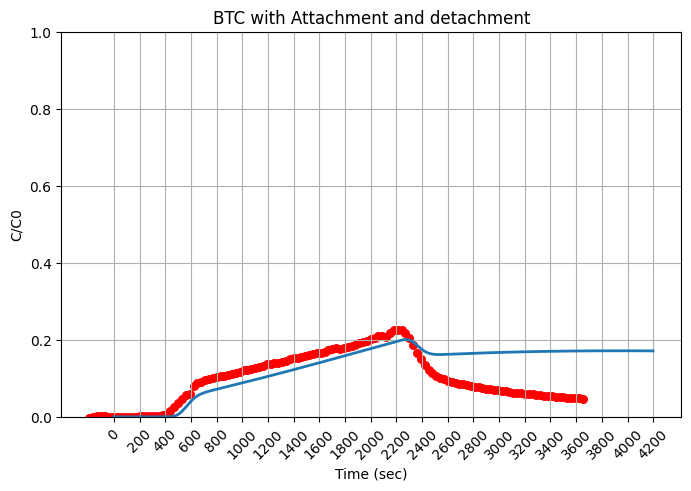

2272
0.20086991774461793
2272
RMSE = 0.059201931387713076


In [8]:
# ATTACHMENT + DETACHMENT
plt.close('all')

L = 15.0
dx = 0.1
porosity = 0.4
v = 0.01 / porosity
D = 0.001312
dt = 1
t_end = 4200

df = pd.read_excel("10mM(1) MP.xlsx", sheet_name = 1)
exp_time = pd.to_numeric(df.iloc[2:, 0], errors='coerce')
exp_time -= 250
exp_btc  = pd.to_numeric(df.iloc[2:, 1], errors='coerce')
exp_time = exp_time.dropna()
exp_btc = exp_btc.dropna()

Cin = 1.0
injection_time = 1800

katt = 0.005
kdet = 0.0005

Smax = 1.0

x = np.arange(0, L + dx, dx)

Nx = len(x)
Nt = int(t_end / dt)

C = np.zeros(Nx)
S = np.zeros(Nx)

BTC = []
time = []

for n in range(Nt):

    t = n * dt

    C_old = C.copy()
    S_old = S.copy()

    if t <= injection_time:
        C[0] = Cin
    else:
        C[0] = 0.0

    C[-1] = C[-2]
    S[0] = S_old[0]
    S[-1] = S_old[-2]

    for i in range(1, Nx - 1):

        advective_term = (-v * (C_old[i] - C_old[i - 1]) / dx)

        dispersive_term = (D * ( C_old[i + 1] - 2 * C_old[i] + C_old[i - 1]) / dx**2)

        blocking_factor = 1

        if blocking_factor < 0:
            blocking_factor = 0

        attachment_term = (-katt * C_old[i] * blocking_factor)

        detachment_term = (kdet * S_old[i])

        C[i] = (C_old[i] + dt * (advective_term + dispersive_term + attachment_term + detachment_term))


        S[i] = (S_old[i] + dt * (katt * C_old[i] * blocking_factor - kdet * S_old[i]))

    BTC.append(C[-1])
    time.append(t)

plt.figure(figsize=(8,5))
plt.plot(time, BTC, linewidth=2)

plt.xlabel("Time (sec)")
plt.ylabel("C/C0")
plt.xticks(np.arange(0, t_end + 1, 200), rotation = 45)
plt.ylim(0,1)
plt.title("BTC with Attachment and detachment")

plt.grid(True)
plt.scatter(
    exp_time,
    exp_btc,
    color='red',
    s=30,
    label='Experimental Tracer'
)

plt.show()
peak_index = np.argmax(BTC)

print(time[peak_index])
print(BTC[peak_index])
idx = np.argmin(np.abs(np.array(BTC)-0.5))
print(time[idx])

model_at_exp = np.interp(
    exp_time,
    time,
    BTC
)
rmse = np.sqrt(
    np.mean(
        (model_at_exp - exp_btc)**2
    )
)

print("RMSE =", rmse)

# CONCLUSION = These set of values (0.005,0.0005) gives very less RMSE value equal to 0.059

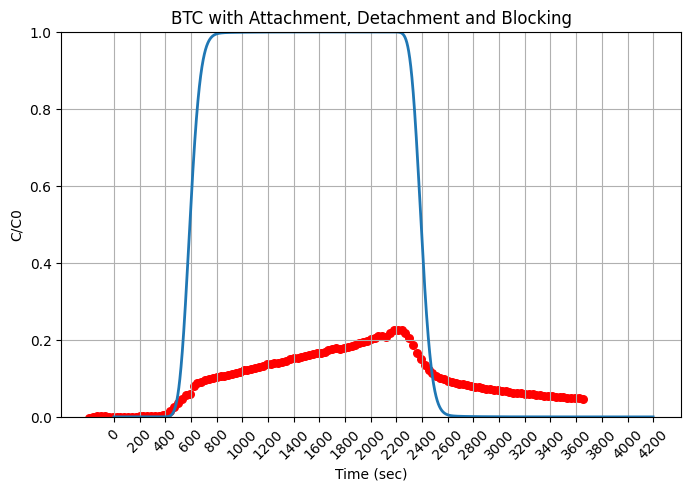

2141
0.9999970737123468
592
RMSE = 0.5618118192481307


In [11]:
# ATTACHMENT + DETACHMENMT + BLOCKING

L = 15.0
dx = 0.1
porosity = 0.4
v = 0.01 / porosity
D = 0.001312
dt = 1
t_end = 4200

df = pd.read_excel("10mM(1) MP.xlsx", sheet_name = 1)
exp_time = pd.to_numeric(df.iloc[2:, 0], errors='coerce')
exp_time -= 250
exp_btc  = pd.to_numeric(df.iloc[2:, 1], errors='coerce')
exp_time = exp_time.dropna()
exp_btc = exp_btc.dropna()

Cin = 1.0
injection_time = 1800

katt = 0.00001
kdet = 0.005

Smax = 1.0

x = np.arange(0, L + dx, dx)

Nx = len(x)
Nt = int(t_end / dt)

C = np.zeros(Nx)
S = np.zeros(Nx)

BTC = []
time = []

for n in range(Nt):

    t = n * dt

    C_old = C.copy()
    S_old = S.copy()

    if t <= injection_time:
        C[0] = Cin
    else:
        C[0] = 0.0

    C[-1] = C[-2]
    S[0] = S_old[0]
    S[-1] = S_old[-2]

    for i in range(1, Nx - 1):

        advective_term = (-v * (C_old[i] - C_old[i - 1]) / dx)

        dispersive_term = (D * (C_old[i + 1] - 2 * C_old[i] + C_old[i - 1]) / dx**2)

        blocking_factor = (1 - S[i]/Smax)

        if blocking_factor < 0:
            blocking_factor = 0

        attachment_term = ( -katt * C_old[i] * blocking_factor)

        detachment_term = (kdet * S_old[i])

        C[i] = (C_old[i] + dt * (advective_term + dispersive_term + attachment_term + detachment_term))

        S[i] = ( S_old[i] + dt * (katt * C_old[i] * blocking_factor - kdet * S_old[i]))

    BTC.append(C[-1])
    time.append(t)

plt.figure(figsize=(8,5))
plt.plot(time, BTC, linewidth=2)

plt.xlabel("Time (sec)")
plt.ylabel("C/C0")
plt.xticks(np.arange(0, t_end + 1, 200), rotation = 45)
plt.ylim(0,1)
plt.title("BTC with Attachment, Detachment and Blocking")

plt.grid(True)
plt.scatter(
    exp_time,
    exp_btc,
    color='red',
    s=30,
    label='Experimental Tracer'
)

plt.show()
peak_index = np.argmax(BTC)

print(time[peak_index])
print(BTC[peak_index])
idx = np.argmin(np.abs(np.array(BTC)-0.5))
print(time[idx])

model_at_exp = np.interp(
    exp_time,
    time,
    BTC
)
rmse = np.sqrt(
    np.mean(
        (model_at_exp - exp_btc)**2
    )
)

print("RMSE =", rmse)

# CONCLUSION = After adding blocking even for set of values of k_att and k_det values that gave very less RMSE value tend to give very high RMSE and shoes very great deviation indicating another factor to be prensent possible straining

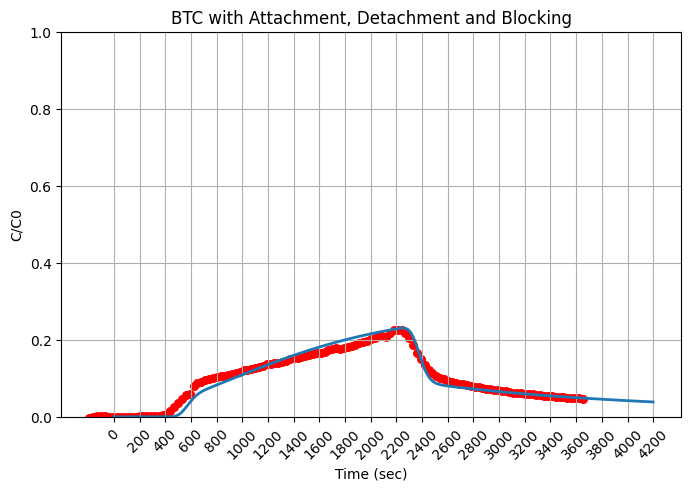

2251
0.2308020384154575
2251
RMSE = 0.01275086567413963


In [12]:
#ATTACHMENT + DETACHMENT + BLOCKING + STRAINING

L = 15.0
dx = 0.1
porosity = 0.4
v = 0.01 / porosity
D = 0.001312
dt = 1
t_end = 4200

df = pd.read_excel("10mM(1) MP.xlsx", sheet_name = 1)
exp_time = pd.to_numeric(df.iloc[2:, 0], errors='coerce')
exp_time -= 250
exp_btc  = pd.to_numeric(df.iloc[2:, 1], errors='coerce')
exp_time = exp_time.dropna()
exp_btc = exp_btc.dropna()

L = 15.0
dx = 0.1
porosity = 0.4
v = 0.01/ porosity
D = 0.001
dt = 1
t_end = 4200

Cin = 1.0
injection_time = 1800

katt = 0.0028
kdet = 0.0006
kstr0 = 0.0032
beta = 0.055

Smax = 1.0

x = np.arange(0, L + dx, dx)

Nx = len(x)
Nt = int(t_end / dt)

C = np.zeros(Nx)
S = np.zeros(Nx)
Sstr = np.zeros(Nx)

BTC = []
time = []

for n in range(Nt):

    t = n * dt

    C_old = C.copy()
    S_old = S.copy()
    Sstr_old = Sstr.copy()

    if t <= injection_time:
        C[0] = Cin
    else:
        C[0] = 0.0

    C[-1] = C[-2]
    S[0] = S_old[0]
    S[-1] = S_old[-2]

    for i in range(1, Nx - 1):

        advective_term = (-v * (C_old[i] - C_old[i - 1]) / dx)

        dispersive_term = (D * (C_old[i + 1] - 2 * C_old[i] + C_old[i - 1]) / dx**2)

        blocking_factor = (1 - S_old[i]/Smax)

        if blocking_factor < 0:
            blocking_factor = 0

        attachment_term = ( -katt * C_old[i] * blocking_factor)

        detachment_term = (kdet * S_old[i])
        kstr_local = kstr0 * np.exp(-beta * x[i])
        straining_term = (-kstr_local * C_old[i])

        C[i] = (C_old[i] + dt * (advective_term + dispersive_term + attachment_term + detachment_term + straining_term))

        S[i] = (S_old[i] + dt * (katt * C_old[i] * blocking_factor - kdet * S_old[i]))

        Sstr[i] = (Sstr_old[i] + dt * (kstr0 * C_old[i]))


        C[i] = ( C_old[i] + dt * (advective_term + dispersive_term + attachment_term + detachment_term + straining_term))

        S[i] = (S_old[i] + dt * (katt * C_old[i] * blocking_factor - kdet * S_old[i]))

        Sstr[i] = (Sstr_old[i] + dt * (kstr0 * C_old[i]))

    BTC.append(C[-1])
    time.append(t)

plt.figure(figsize=(8,5))
plt.plot(time, BTC, linewidth=2)

plt.xlabel("Time (sec)")
plt.ylabel("C/C0")
plt.xticks(np.arange(0, t_end + 1, 200), rotation = 45)
plt.ylim(0,1)
plt.title("BTC with Attachment, Detachment and Blocking")

plt.grid(True)
plt.scatter(
    exp_time,
    exp_btc,
    color='red',
    s=30,
    label='Experimental Tracer'
)

plt.show()
peak_index = np.argmax(BTC)

print(time[peak_index])
print(BTC[peak_index])
idx = np.argmin(np.abs(np.array(BTC)-0.5))
print(time[idx])

model_at_exp = np.interp(
    exp_time,
    time,
    BTC
)
rmse = np.sqrt(
    np.mean(
        (model_at_exp - exp_btc)**2
    )
)

print("RMSE =", rmse)

plt.show()
# After adding straining (function of column hieght) we get the least value for RMSE that is 0.012.

In [13]:
pip install scipy

In [4]:
from scipy.optimize import differential_evolution
from numba import njit

df = pd.read_excel("10mM(1) MP.xlsx",sheet_name=1)

exp_time = pd.to_numeric(df.iloc[2:,0],errors='coerce')
exp_btc  = pd.to_numeric(df.iloc[2:,1],errors='coerce')

exp_time -=250

exp_time = exp_time.dropna()
exp_btc  = exp_btc.dropna()
exp_time = exp_time.to_numpy(dtype=np.float64)
exp_btc = exp_btc.to_numpy(dtype=np.float64)



L=15
dx=0.1
porosity=0.4
v=0.01/porosity
D=0.001312

dt=1
t_end=4200


Cin=1
injection_time=1800

x=np.arange(0,L+dx,dx)

Nx=len(x)
Nt=int(t_end/dt)



@njit(cache = True)
def run_model(params):


    alpha,kdet,kstr0,beta,Smax=params


    katt=0.1*alpha


    C=np.zeros(Nx)
    S=np.zeros(Nx)
    Sstr=np.zeros(Nx)



    BTC=np.zeros(Nt)
    time=np.zeros(Nt)



    for n in range(Nt):


        t=n*dt


        C_old=C.copy()
        S_old=S.copy()
        Sstr_old=Sstr.copy()



        if t<=injection_time:
            C[0]=Cin

        else:
            C[0]=0



        C[-1]=C[-2]



        for i in range(1,Nx-1):



            adv=(-v * (C_old[i]-C_old[i-1]) / dx)

            disp=(D * (C_old[i+1]-2*C_old[i]+C_old[i-1]) / dx**2)


            block=1-S_old[i]/Smax

            if block<0:
                block=0



            attach=(-katt * C_old[i] * block)



            detach=(kdet* S_old[i])

            kstr_local = kstr0 * np.exp(-beta * x[i])

            strain=(-kstr_local * C_old[i])



            C[i]=(C_old[i] + dt * (adv + disp + attach + detach + strain))



            S[i]=(S_old[i] + dt * (katt * C_old[i] * block - kdet*S_old[i]))

            Sstr[i]=(Sstr_old[i] + dt * (kstr0 * C_old[i]))

        BTC[n] =  C[-1]
        time[n] = t



    model=np.interp(
                    exp_time,
                    time,
                    BTC
                    )



    rmse=np.sqrt(
                    np.mean(
                            (
                             model-exp_btc
                             )**2
                           )
                 )



    return rmse




bounds=[


(0,1),

(0,0.005),

(0,0.02),

(0,1),

(0.5,5)

]




result=differential_evolution(

                                run_model,

                                bounds,

                                popsize=20,

                                maxiter=100,

                                polish=True,

                                workers  = -1,

                                updating='deferred',

                                seed=42

                             )



alpha,kdet,kstr0,beta,Smax=result.x


print()

print("Best alpha :",alpha)

print("Best kdet :",kdet)

print("Best kstr0 :",kstr0)

print("Best beta :",beta)

print("Best Smax :",Smax)

print()

print("Minimum RMSE :",result.fun)


Best alpha : 0.020933819865890824
Best kdet : 0.0008718174612461061
Best kstr0 : 0.006637408004049715
Best beta : 0.17640554764278588
Best Smax : 1.5132062352466369

Minimum RMSE : 0.0070994121655922


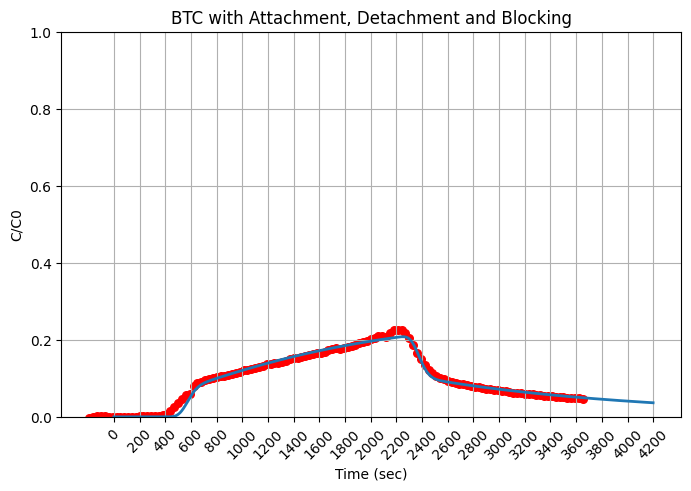

2251
0.20821590302187476
2251
RMSE = 0.007373828172840749


In [5]:
#FINAL BTC OBTAINED BY PARAMETRES FIXED BY DIFFERENTIAL EVOLUTION

L = 15.0
dx = 0.1
porosity = 0.4
v = 0.01 / porosity
D = 0.001312
dt = 1
t_end = 4200

df = pd.read_excel("10mM(1) MP.xlsx", sheet_name = 1)
exp_time = pd.to_numeric(df.iloc[2:, 0], errors='coerce')
exp_time -= 250
exp_btc  = pd.to_numeric(df.iloc[2:, 1], errors='coerce')
exp_time = exp_time.dropna()
exp_btc = exp_btc.dropna()

L = 15.0
dx = 0.1
porosity = 0.4
v = 0.01/ porosity
D = 0.001
dt = 1
t_end = 4200

Cin = 1.0
injection_time = 1800

alpha = 0.020933819865890824

katt = 0.1 * alpha
kdet = 0.0008718174612461061
kstr0 = 0.006637408004049715
beta = 0.17640554764278588

Smax = 1.5132062352466369

x = np.arange(0, L + dx, dx)

Nx = len(x)
Nt = int(t_end / dt)

C = np.zeros(Nx)
S = np.zeros(Nx)
Sstr = np.zeros(Nx)

BTC = []
time = []

for n in range(Nt):

    t = n * dt

    C_old = C.copy()
    S_old = S.copy()
    Sstr_old = Sstr.copy()

    if t <= injection_time:
        C[0] = Cin
    else:
        C[0] = 0.0

    C[-1] = C[-2]
    S[0] = S_old[0]
    S[-1] = S_old[-2]

    for i in range(1, Nx - 1):

        advective_term = (-v * (C_old[i] - C_old[i - 1]) / dx)

        dispersive_term = (D * (C_old[i + 1] - 2 * C_old[i] + C_old[i - 1]) / dx**2)

        blocking_factor = (1 - S_old[i]/Smax)

        if blocking_factor < 0:
            blocking_factor = 0

        attachment_term = ( -katt * C_old[i] * blocking_factor)

        detachment_term = (kdet * S_old[i])
        kstr_local = kstr0 * np.exp(-beta * x[i])
        straining_term = (-kstr_local * C_old[i])

        C[i] = (C_old[i] + dt * (advective_term + dispersive_term + attachment_term + detachment_term + straining_term))

        S[i] = (S_old[i] + dt * (katt * C_old[i] * blocking_factor - kdet * S_old[i]))

        Sstr[i] = (Sstr_old[i] + dt * (kstr0 * C_old[i]))


        C[i] = ( C_old[i] + dt * (advective_term + dispersive_term + attachment_term + detachment_term + straining_term))

        S[i] = (S_old[i] + dt * (katt * C_old[i] * blocking_factor - kdet * S_old[i]))

        Sstr[i] = (Sstr_old[i] + dt * (kstr0 * C_old[i]))

    BTC.append(C[-1])
    time.append(t)

plt.figure(figsize=(8,5))
plt.plot(time, BTC, linewidth=2)

plt.xlabel("Time (sec)")
plt.ylabel("C/C0")
plt.xticks(np.arange(0, t_end + 1, 200), rotation = 45)
plt.ylim(0,1)
plt.title("BTC with Attachment, Detachment and Blocking")

plt.grid(True)
plt.scatter(
    exp_time,
    exp_btc,
    color='red',
    s=30,
    label='Experimental Tracer'
)

plt.show()
peak_index = np.argmax(BTC)

print(time[peak_index])
print(BTC[peak_index])
idx = np.argmin(np.abs(np.array(BTC)-0.5))
print(time[idx])

model_at_exp = np.interp(
    exp_time,
    time,
    BTC
)
rmse = np.sqrt(
    np.mean(
        (model_at_exp - exp_btc)**2
    )
)

print("RMSE =", rmse)

plt.show()
# After adding straining (function of column hieght) we get the least value for RMSE that is 0.012.